# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Load data from simulation of system dynamic model. 
% Data file contains the variables: model dT t u x z
load readonly/simOut.mat
t = t(1:10000); % crop "t" because simulation is slow; this shortens sim time.
q = [model.k, model.b, model.m]';

% We require the Octave control-systems "package" to implement "expm".
pkg load control

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

### Helper functions for the sigma-point Kalman filter for parameter estimation
The next notebook cells implement the initialization and iteration functions for the SPKF for parameter estimation.

In [3]:
% SPKF initialization function, called once at the beginning of the simulation
function spkfData = initSPKFid(q0,SigmaQ0,SigmaW,SigmaD,u1,x1)
  spkfData.qhat   = q0;          % Initial state description  
  spkfData.SigmaQ = SigmaQ0;  % Initial estimation-error covariance 
  spkfData.SigmaD = SigmaD;   % Sensor-noise covariance 
  spkfData.SigmaW = SigmaW;   % Process-noise covariance
  spkfData.priorU = u1;       % Previous value of input force
  spkfData.priorX = x1;
  spkfData.Qbump  = 5;        % In case SigmaQ collapses
  spkfData.Snoise = real(chol(spkfData.SigmaD,'lower'));
  
  % SPKF specific parameters
  nq = length(spkfData.qhat); spkfData.nq = nq; % state-vector length
  nd = size(SigmaD,1); spkfData.nd = nd;     % measurement-vector length
  nu = 1; spkfData.nu = nu;                  % input-vector length
  nw = size(SigmaQ0,1); spkfData.nw = nw; % process-noise-vector length
  nv = size(SigmaD,1); spkfData.nv = nv; % sensor-noise-vector length
  na = nq+nd; spkfData.na = na;     % augmented-state-vector length
  
  h = sqrt(3); 
  spkfData.h = h; % SPKF/CDKF tuning factor  
  Weight1 = (h*h-na)/(h*h); % weighting factors when computing mean
  Weight2 = 1/(2*h*h);      % and covariance
  spkfData.Wm = [Weight1; Weight2*ones(2*na,1)]; % mean
  spkfData.Wc = spkfData.Wm;                     % covar
end

In [4]:
% SPKF iteration function, called once every measurement interval
function [qhat,bounds,spkfData] = iterSPKFid(uk,xk,zk,dT,spkfData)
  SQRT = @(x) sqrt(max(0,x)); % "Safe" square root

  % Get data stored in spkfData structure
  priorU = spkfData.priorU;
  priorX = spkfData.priorX;
  SigmaQ = spkfData.SigmaQ;
  SigmaW = spkfData.SigmaW;
  qhat = spkfData.qhat;
  nq = spkfData.nq;
  nv = spkfData.nv;
  na = spkfData.na;
  Snoise = spkfData.Snoise;
  Wc = spkfData.Wc;
  
  % Step 1a: Parameter prediction time update
  %          - Do nothing. qhat(minus,k) = qhat(plus,k-1)
  
  % Step 1b: Prediction-error covariance time update
  SigmaQ = SigmaQ + SigmaW;
  
  % Step 1c: Output prediction
  % Step 1c-1: Create augmented SigmaQ and qhat
  [sigmaQa,p] = chol(SigmaQ,'lower'); 
  if p>0
    fprintf('Cholesky error.  Recovering...\n');
    theAbsDiag = abs(diag(SigmaQ));
    sigmaQa = blkdiag(max(SQRT(theAbsDiag),SQRT(spkfData.SigmaW)));
  end
  sigmaQa=blkdiag(real(sigmaQa),Snoise);
  qhata = [qhat; zeros([nv 1])];
  % NOTE: sigmaQa is lower-triangular

  % Step 1c-2: Calculate SigmaQ points (strange indexing of qhata to 
  % avoid "repmat" call, which is very inefficient in MATLAB)
  Qa = qhata(:,ones([1 2*na+1])) + ...
       spkfData.h*[zeros([na 1]), sigmaQa, -sigmaQa];

  % Step 1c-3: Compute prediction of [xk;zk]
  D = outputEqn(Qa(1:nq,:),priorU,xk,priorX,dT,Qa(nq+1:end,:)); 
  dhat = D*spkfData.Wm; % prediction of [xk;zk]

  % Step 2a: Estimator gain matrix
  Qs = Qa(1:nq,:) - qhat(:,ones([1 2*na+1]));
  Ds = D - dhat(:,ones([1 2*na+1]));
  SigmaQD = Qs*diag(Wc)*Ds';
  SigmaD  = Ds*diag(Wc)*Ds';
  L = SigmaQD/SigmaD; 

  % Step 2b: State estimate measurement update
  r = [xk;zk] - dhat; % residual.  Use to check for sensor errors...
  if r*r' > 100*trace(SigmaD), L(:)=0.0; end 
  qhat = qhat + L*r;

  % Step 2c: Error covariance measurement update
  SigmaQ = SigmaQ - L*SigmaD*L';

  % Q-bump code
  if r*r' > 16*trace(SigmaD) % bad output estimate by 4 std. devs, bump Q 
    fprintf('Bumping SigmaX\n');
    SigmaQ = SigmaQ*spkfData.Qbump;
  end
  [~,S,V] = svd(SigmaQ); % Implement Higham method to help robustness
  HH = V*S*V';
  SigmaQ = (SigmaQ + SigmaQ' + HH + HH')/4; 
  
  % Save data in ekfData structure for next time...
  spkfData.priorU = uk;
  spkfData.priorX = xk;
  spkfData.SigmaQ = SigmaQ;
  spkfData.qhat = qhat;
  bounds = 3*sqrt(diag(SigmaQ));
  
  % Calculate [xk;zk] for all of parameter vectors in qhat
  function dhat = outputEqn(qhat,priorU,xk,priorX,dT,dnoise)
    % Parameters (in order) are k, b, m
    
    dhat = zeros(length(xk)+1,size(qhat,2));
    for kk = 1:size(qhat,2)
      k = qhat(1,kk); b = qhat(2,kk); m = qhat(3,kk); 
      A = [0 1; -k/m -b/m]; % Specify continuous-time model
      B = [0; 1/m]; 
      C = [1 0]; 
      Ad = expm(A*dT); Bd = (A\(Ad-eye(2)))*B;
      
      dhat(:,kk) = [Ad*priorX + Bd*priorU; C*xk]; % [xk;zk] pred
    end
    dhat = dhat + dnoise;
  end
end

### Implementing the sigma-point Kalman filter for parameter estimation
The next notebook cells implement the main code of the sigma-point Kalman filter.

In [5]:
% Determine number of states and timesteps
[nx,~] = size(x); nt = length(t);

In [6]:
% Reserve storage for computed results, for plotting
nq         = 3; % this many parameters to estimate
qhatstore  = zeros(nq,nt);
boundstore = zeros(nq,nt);

% Initial estimate and covariance values
q0      = [2;1;40];
SigmaQ0 = diag((q-q0)/3)^2; % uncertainty of initial parameters
SigmaW  = diag(1e-8*[1 1 10]);
SigmaD  = blkdiag(model.SigmaW,model.SigmaV);

% Create spkfData structure and initialize variables 
spkfData = initSPKFid(q0,SigmaQ0,SigmaW,SigmaD,u(1),x(:,1));

% Now, enter loop for remainder of time, where we update the SPKF
% once per sample interval
for k = 2:length(t)
  uk = u(k);   % "measure" input force
  xk = x(:,k); % "measure" true state
  zk = z(k);   % "measure" nonlinear output
  
  % Update parameters
  [qhatstore(:,k),boundstore(:,k),spkfData] = iterSPKFid(uk,xk,zk,dT,spkfData);
  if mod(k,2000) == 0
    fprintf('Completed %d out of %d iterations\n',k,length(t));
  end 
end
spkfErr = q - qhatstore;
spkfBnd = boundstore;

Completed 2000 out of 10000 iterations
Completed 4000 out of 10000 iterations
Completed 6000 out of 10000 iterations
Completed 8000 out of 10000 iterations
Completed 10000 out of 10000 iterations


### Plot simulation outputs from the sigma-point Kalman filter
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

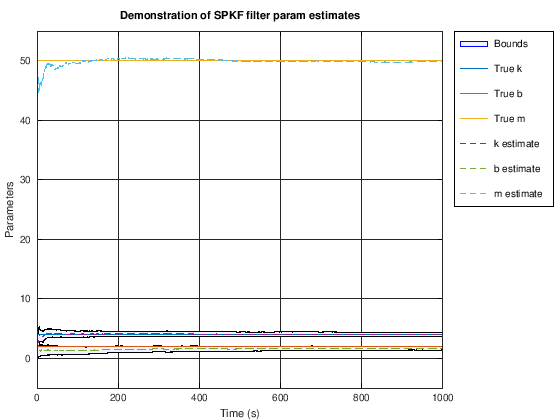

In [7]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [qhatstore-boundstore fliplr(qhatstore+boundstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 

h2 = plot([0 t(end)],[q,q],t,qhatstore','--'); ylim([-5 55]);
legend([h2;h1a],{'True k','True b','True m','k estimate',...
  'b estimate','m estimate','Bounds'},"Location","bestoutside"); 
title('Demonstration of SPKF filter param estimates'); 
xlabel('Time (s)'); ylabel('Parameters'); 

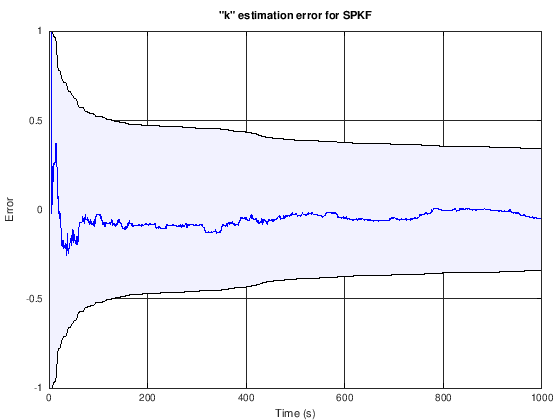

In [8]:
fill([t fliplr(t)],[-boundstore(1,:) fliplr(boundstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,spkfErr(1,:),'b'); ylim([-1 1])
title('"k" estimation error for SPKF'); 
xlabel('Time (s)'); ylabel('Error'); 

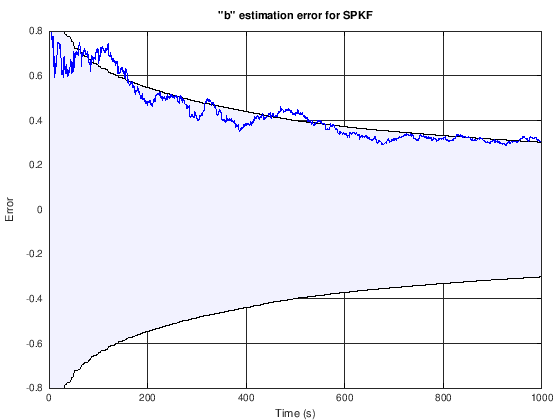

In [9]:
fill([t fliplr(t)],[-boundstore(2,:) fliplr(boundstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,spkfErr(2,:),'b'); ylim([-0.8 0.8])
title('"b" estimation error for SPKF'); 
xlabel('Time (s)'); ylabel('Error'); 

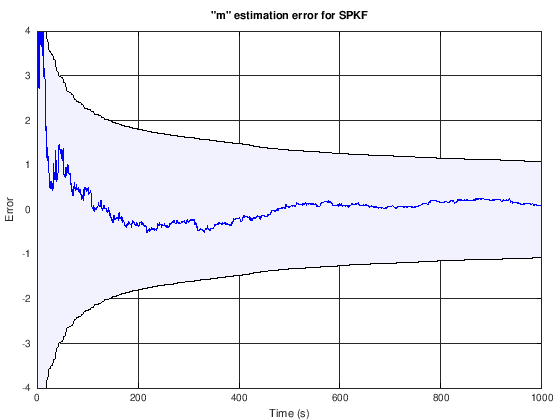

In [10]:
fill([t fliplr(t)],[-boundstore(3,:) fliplr(boundstore(3,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,spkfErr(3,:),'b'); ylim([-4 4])
title('"m" estimation error for SPKF'); 
xlabel('Time (s)'); ylabel('Error'); 

In [11]:
% Compute and output some statistics
fprintf('RMS parameter estimation error = %g\n',rms(spkfErr(:)));
ind = find(abs(spkfErr(:))>boundstore(:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundstore(:))*100);

RMS parameter estimation error = 0.559284
Time error outside bounds = 9.9%


In [12]:
% Compute and output some statistics
fprintf('RMS parameter estimation error = %g\n',rms(spkfErr(1,:)));
ind = find(abs(spkfErr(1,:))>boundstore(1,:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundstore(1,:))*100);

RMS parameter estimation error = 0.144737
Time error outside bounds = 0.1%


In [13]:
% Compute and output some statistics
fprintf('RMS parameter estimation error = %g\n',rms(spkfErr(2,:)));
ind = find(abs(spkfErr(2,:))>boundstore(2,:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundstore(2,:))*100);

RMS parameter estimation error = 0.447509
Time error outside bounds = 29.49%
